# Example 6: Validating a single generative agent using the Household Pulse Survey

Example 6 shows how a household generative agent implemented in pyrecodes is validated using the US Census Household Pulse Survey. Generative agent makes decisions using LLM's logic conditioned on its socio-economic parameters, building damage and access to infrastructure services. This example shows how to construct the generative agent, provide inputs and compare its outputs with decision-making of real households in the US.

Please refer to the **pyrecodes** [Example 6 page](https://nikolablagojevic.github.io/pyrecodes/html/usage/examples/example_6.html) for further details.

In [ ]:
# Create household info for all households that experienced a disaster and prepare for generative agent input
from pyrecodes.household.convert_survey_to_household_info import convert_survey_to_household_info
import pandas as pd

def conditions_to_include_household_met(household_info):
    # define conditions to include household in the analysis
    if household_info['BuildingDamage'] is None:
        return False
    if household_info['DisplacementDuration'] is None:
        return False
    if household_info['WaterAccess'] is None:
        return False    
    if household_info['PowerAccess'] is None:
        return False
    if household_info['FoodAccess'] is None:
        return False
    if household_info['UnsanitaryConditions'] is None:
        return False
    if len(household_info['DisasterType']) != 1:
        # avoid households that experienced more than one disaster type, as we cannot determine which disaster type to use for the agent input
        return False
    for key, value in household_info['SocioEconomicParameters'].items():
        if value is None:
            return False
    return True

# get individual household surveys and prepare inputs for a generative agent
household_info_template = {'SocioEconomicParameters': {'State': None, 'MSA': None, 'Tenure': None, 'Income': None, 'Occupants': None, 'Kids5years': None, 'Kids5-11years': None, 'Kids12-17years': None, 'EmploymentStatus': None},
                            'BuildingDamage': None,
                            'DisasterType': None,
                            'DisplacementDuration': None,
                            'WaterAccess': None,
                            'PowerAccess': None,
                            'FoodAccess': None,
                            'UnsanitaryConditions': None,
                            'InformGPTMethod': None
                            }

households_info = []

household_pulse_survey_df = pd.read_csv('Example 6/household_pulse_survey_displaced.csv')

for household_survey_row in household_pulse_survey_df[household_pulse_survey_df['ND_DISPLACE'] == 1].iterrows():
    household_info = convert_survey_to_household_info(household_survey_row[1], household_info_template)
 
    if conditions_to_include_household_met(household_info):
        household_info['DisasterType'] = household_info['DisasterType'][0]
        households_info.append(household_info)

print(f"Prepared household information for {len(households_info)} households that experienced a disaster.")

In [ ]:
# create a generative agent, prompt it and compare outputs with actual survey data
import json
import random
import textwrap
from pyrecodes.household.household_survey_gpt import HouseholdSurveyGPT

TEXT_WIDTH = 80
NUM_HOUSEHOLDS_TO_PROCESS = 10
PROMPTING_STRATEGY = 'ReadRuleset'  # options: None (baseline GPT), 'ReadLiterature', 'ReadRuleset'

def header(title):
    print(f"\n{'═' * TEXT_WIDTH}")
    print(f"  {title}")
    print(f"{'═' * TEXT_WIDTH}")

def section(title, content):
    bar = '─' * max(0, TEXT_WIDTH - len(title) - 4)
    print(f"\n┌─ {title} {bar}")
    for paragraph in content.strip().split('\n'):
        if paragraph.strip():
            for line in textwrap.wrap(paragraph, width=TEXT_WIDTH - 4):
                print(f"│  {line}")
        else:
            print("│")
    print(f"└{'─' * (TEXT_WIDTH - 1)}")

def result_line(label, value, match=None):
    suffix = ("  ✓" if match else "  ✗") if match is not None else ""
    print(f"  {label:<32} {value}{suffix}")

def set_prompting_strategy_for_agent(household_info, prompting_strategy):
    household_info['InformGPTMethod'] = prompting_strategy
    return household_info


results = {'AgentDecisions': [], 
           'DisplacementDurationsMappedToDecisions': [],
           'DisplacementDurations': []}

for i, household_info in enumerate(random.sample(households_info, NUM_HOUSEHOLDS_TO_PROCESS)):
    header(f"HOUSEHOLD {i + 1} / {NUM_HOUSEHOLDS_TO_PROCESS}")

    household_info = set_prompting_strategy_for_agent(household_info, PROMPTING_STRATEGY)
    agent = HouseholdSurveyGPT()
    agent.set_parameters(household_info)

    section("PROMPT — DISASTER CONTEXT",      agent.llm.chat_history[0]['content'])
    section("ANSWER — DISASTER CONTEXT",      agent.llm.chat_history[1]['content'])
    section("PROMPT — SOCIOECONOMIC PROFILE", agent.llm.chat_history[2]['content'])
    section("ANSWER — SOCIOECONOMIC PROFILE", agent.llm.chat_history[3]['content'])

    agent.create_time_step_narrative(
        household_info['BuildingDamage'],
        {
            'WaterAccess':          household_info['WaterAccess'],
            'PowerAccess':          household_info['PowerAccess'],
            'FoodAccess':           household_info['FoodAccess'],
            'UnsanitaryConditions': household_info['UnsanitaryConditions'],
        },
        household_info['DisasterType'],
    )
    section("PROMPT — SITUATION NARRATIVE", agent.time_step_narrative_creator.get_narrative())

    agent.decide()

    section("ANSWER — AGENT DECISION", agent.llm.chat_history[-1]['content'])

    decision = agent.decisions[-1]
    actual   = household_info['DisplacementDuration']
    actual_mapped_to_agent_decision = 'LeaveHomeForLessThanAWeek' if 'Less than a week' in actual else 'LeaveHomeForMoreThanAWeek'
    match = (decision == actual_mapped_to_agent_decision)

    print()
    result_line("Agent decision:",               decision)
    result_line("Actual displacement duration:", actual, match=match)

    results['DisplacementDurationsMappedToDecisions'].append(actual_mapped_to_agent_decision)
    results['AgentDecisions'].append(decision)
    results['DisplacementDurations'].append(actual)

savename = f'displacement_durations_vs_agent_decisions_{NUM_HOUSEHOLDS_TO_PROCESS}.json'
with open(savename, 'w') as f:
    json.dump(results, f)
print(f"\nResults saved to {savename}")


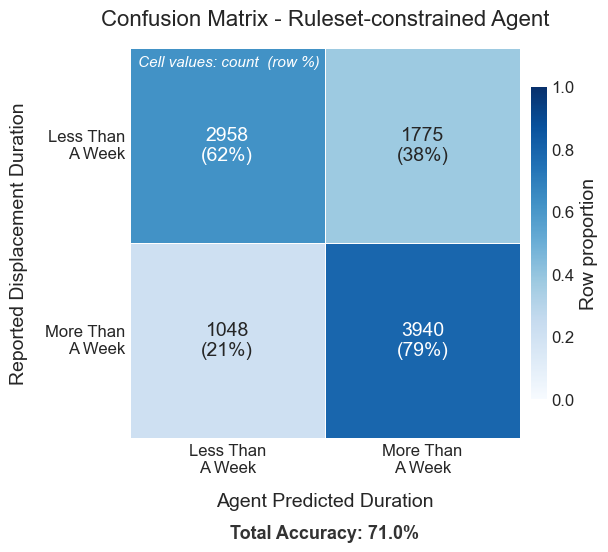

Saved to ./Example 6/confusion_matrix_ruleset.png


In [39]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

loadname = './Example 6/results_cluster_ruleset_gpt.json'
SAVE_PATH = './Example 6/confusion_matrix_ruleset.png'
TITLE = 'Confusion Matrix - Ruleset-constrained Agent'

with open(loadname, 'r') as f:
    results = json.load(f)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': True,
    'legend.facecolor': 'white',
    'legend.framealpha': 0.9,
})

LABELS = ['Less Than\nA Week', 'More Than\nA Week']

def plot_confusion_matrix(cm_counts, title, accuracy):
    cm_norm = cm_counts / cm_counts.sum(axis=1, keepdims=True)
    annots = np.empty_like(cm_counts, dtype=object)
    for i in range(cm_counts.shape[0]):
        for j in range(cm_counts.shape[1]):
            annots[i, j] = f"{cm_counts[i, j]}\n({cm_norm[i, j]:.0%})"

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm_norm,
        annot=annots,
        fmt='',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        square=True,
        vmin=0,
        vmax=1.0,
        annot_kws={'size': 14},
        ax=ax,
        cbar_kws={'shrink': 0.8, 'label': 'Row proportion', 'pad': 0.02},
        xticklabels=LABELS,
        yticklabels=LABELS,
    )
    ax.set_xlabel('Agent Predicted Duration', labelpad=12)
    ax.set_ylabel('Reported Displacement Duration', labelpad=12)
    ax.set_title(title, pad=16)
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', rotation=0, labelsize=12)
    ax.text(
        0.02, 0.98,
        f'Cell values: count  (row %)',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=11, color='white', style='italic',
    )
    ax.text(
        0.5, -0.22,
        f'Total Accuracy: {accuracy:.1%}',
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=13, fontweight='bold', color='#333333',
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved to {SAVE_PATH}')


cm_counts = confusion_matrix(results['DisplacementDurationsMappedToDecisions'], results['AgentDecisions'])
accuracy = cm_counts.diagonal().sum() / cm_counts.sum()
plot_confusion_matrix(cm_counts, title=TITLE, accuracy=accuracy)
